In [3]:
!pip install nltk wordcloud

In [4]:
import nltk

In [5]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [6]:
from google.colab import files

uploaded = files.upload()

Saving twitter_training.csv.zip to twitter_training.csv.zip


In [8]:
!unzip twitter_training.csv.zip

Archive:  twitter_training.csv.zip
  inflating: twitter_training.csv    


In [9]:
import pandas as pd

df = pd.read_csv(
    "twitter_training.csv",
    header=None,
    names=["ID", "Entity", "Sentiment", "Tweet"]
)

df.head()

,ID,Entity,Sentiment,Tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [10]:
df.shape

(74682, 4)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ID         74682 non-null  int64 
 1   Entity     74682 non-null  object
 2   Sentiment  74682 non-null  object
 3   Tweet      73996 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


In [12]:
df.isnull().sum()

,0
ID,0
Entity,0
Sentiment,0
Tweet,686


In [13]:
df['Sentiment'].value_counts()

,count
Sentiment,
Negative,22542
Positive,20832
Neutral,18318
Irrelevant,12990


In [14]:
# Check missing values
df.isnull().sum()

,0
ID,0
Entity,0
Sentiment,0
Tweet,686


In [15]:
# Remove rows with missing tweets
df = df.dropna()

# Verify
df.isnull().sum()

,0
ID,0
Entity,0
Sentiment,0
Tweet,0


In [16]:
print("Before:", df.shape)

df = df.drop_duplicates()

print("After:", df.shape)

Before: (73996, 4)
After: (71656, 4)


In [17]:
df = df[df['Sentiment'] != 'Irrelevant']

df['Sentiment'].value_counts()

,count
Sentiment,
Negative,21698
Positive,19713
Neutral,17708


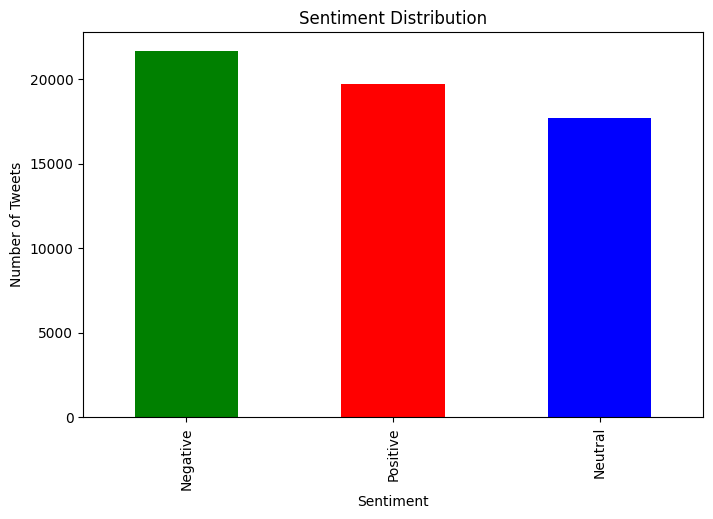

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

df['Sentiment'].value_counts().plot(
    kind='bar',
    color=['green','red','blue']
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")

plt.show()

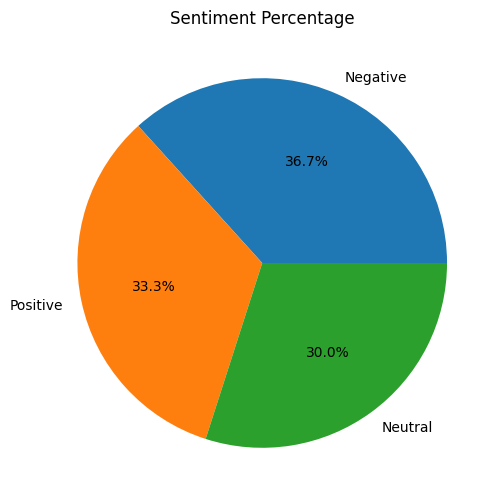

In [19]:
plt.figure(figsize=(6,6))

df['Sentiment'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel("")

plt.title("Sentiment Percentage")

plt.show()

In [20]:
df['Tweet_Length'] = df['Tweet'].astype(str).apply(len)

df['Tweet_Length'].describe()

,Tweet_Length
count,59119.000000
mean,110.212250
std,79.481553
min,1.000000
25%,48.000000
50%,92.000000
75%,154.000000
max,957.000000


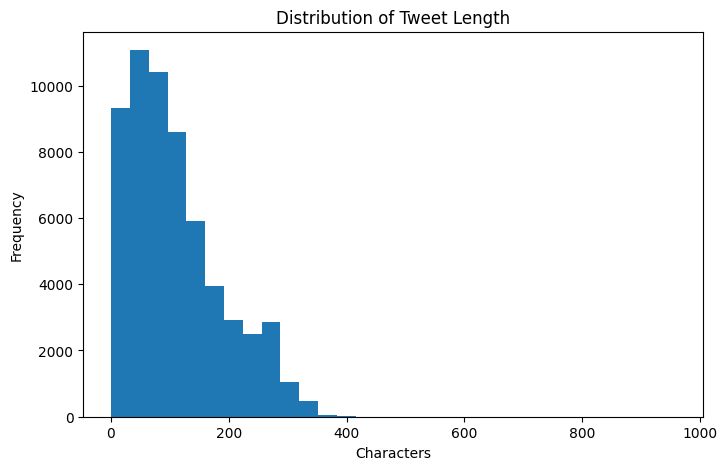

In [21]:
plt.figure(figsize=(8,5))

plt.hist(df['Tweet_Length'], bins=30)

plt.title("Distribution of Tweet Length")

plt.xlabel("Characters")

plt.ylabel("Frequency")

plt.show()

In [22]:
import re
import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [23]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [24]:
def clean_text(text):

    # Convert to string
    text = str(text)

    # Lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove @mentions
    text = re.sub(r'@\w+', '', text)

    # Remove hashtags (# only, keep the word)
    text = re.sub(r'#', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove extra spaces
    text = text.strip()

    # Tokenize
    words = text.split()

    # Remove stopwords & lemmatize
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    # Join back
    return " ".join(words)

In [25]:
df['Clean_Tweet'] = df['Tweet'].apply(clean_text)

In [26]:
df[['Tweet', 'Clean_Tweet']].head(10)

,Tweet,Clean_Tweet
0,im getting on borderlands and i will murder yo...,im getting borderland murder
1,I am coming to the borders and I will kill you...,coming border kill
2,im getting on borderlands and i will kill you ...,im getting borderland kill
3,im coming on borderlands and i will murder you...,im coming borderland murder
4,im getting on borderlands 2 and i will murder ...,im getting borderland murder
5,im getting into borderlands and i can murder y...,im getting borderland murder
6,So I spent a few hours making something for fu...,spent hour making something fun dont know huge...
7,So I spent a couple of hours doing something f...,spent couple hour something fun dont know im h...
8,So I spent a few hours doing something for fun...,spent hour something fun dont know im huge bor...
9,So I spent a few hours making something for fu...,spent hour making something fun dont know huge...


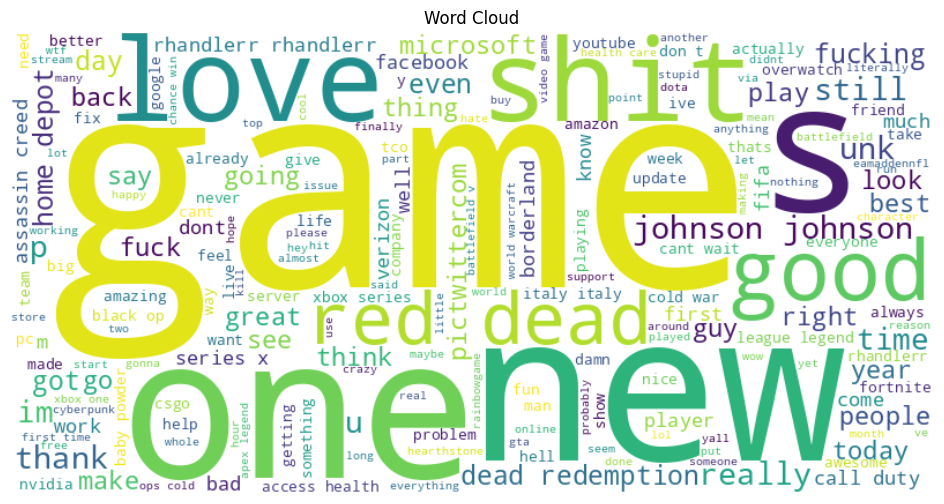

In [27]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(df['Clean_Tweet'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud")
plt.show()

In [28]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df['Sentiment'] = encoder.fit_transform(df['Sentiment'])

df[['Clean_Tweet','Sentiment']].head()

,Clean_Tweet,Sentiment
0,im getting borderland murder,2
1,coming border kill,2
2,im getting borderland kill,2
3,im coming borderland murder,2
4,im getting borderland murder,2


In [29]:
mapping = dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))
print(mapping)

{'Negative': np.int64(0), 'Neutral': np.int64(1), 'Positive': np.int64(2)}


In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000
)

X = tfidf.fit_transform(df['Clean_Tweet'])

y = df['Sentiment']

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [32]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [33]:
y_pred = lr.predict(X_test)

In [34]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.7446718538565629


In [35]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.78      0.80      0.79      4404
           1       0.69      0.68      0.68      3454
           2       0.76      0.75      0.75      3966

    accuracy                           0.74     11824
   macro avg       0.74      0.74      0.74     11824
weighted avg       0.74      0.74      0.74     11824



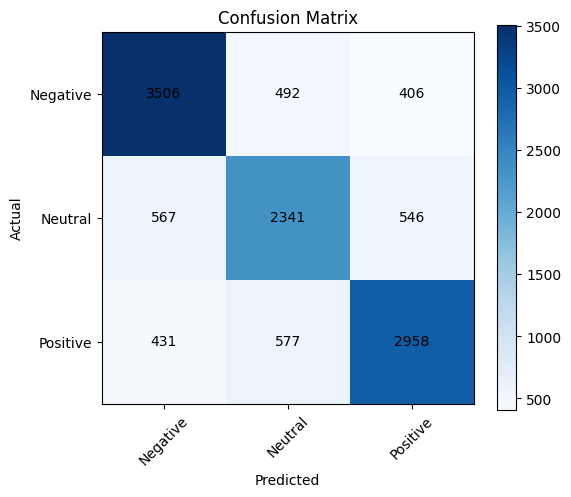

In [36]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.colorbar()

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(range(len(encoder.classes_)), encoder.classes_, rotation=45)
plt.yticks(range(len(encoder.classes_)), encoder.classes_)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.show()

In [37]:
def predict_sentiment(text):
    cleaned = clean_text(text)
    vector = tfidf.transform([cleaned])
    prediction = lr.predict(vector)
    return encoder.inverse_transform(prediction)[0]

In [38]:
predict_sentiment("I absolutely love ChatGPT. It is amazing!")

'Positive'

In [39]:
predict_sentiment("This product is terrible and I hate it.")

'Negative'

In [40]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()

nb.fit(X_train, y_train)

nb_pred = nb.predict(X_test)

from sklearn.metrics import accuracy_score

nb_accuracy = accuracy_score(y_test, nb_pred)

print("Naive Bayes Accuracy:", nb_accuracy)

Naive Bayes Accuracy: 0.7099120433017592


In [41]:
lr_accuracy = accuracy_score(y_test, y_pred)

print("Logistic Regression Accuracy:", lr_accuracy)
print("Naive Bayes Accuracy:", nb_accuracy)

Logistic Regression Accuracy: 0.7446718538565629
Naive Bayes Accuracy: 0.7099120433017592


In [42]:
import joblib

joblib.dump(lr, "sentiment_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")
joblib.dump(encoder, "label_encoder.pkl")

['label_encoder.pkl']

In [43]:
from google.colab import files

files.download("sentiment_model.pkl")
files.download("tfidf_vectorizer.pkl")
files.download("label_encoder.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>